In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Citas_Digital_Sin_Nulos.csv')

print(data)

         BDC        Fecha             Nombre Cliente       Telefono   \
0       Saul    Sin fecha                  Guillermo   No registrado   
1       Saul    Sin fecha                    Roberto   No registrado   
2       Saul    Sin fecha                     Irving   No registrado   
3       Saul    Sin fecha                    Oswaldo   No registrado   
4       Saul    Sin fecha                    Rodrigo   No registrado   
..        ...         ...                         ...            ...   
671       Ana  2026-07-22             Maira Escalante  No registrado   
672  Ignacio   2026-07-22                Zaira Macip   No registrado   
673  Ignacio   2026-07-27            Julio Hernandez   No registrado   
674  Ignacio   2026-07-24           Xhunaxhi Vicente   No registrado   
675  Ignacio   2026-07-29  DR Jairo Rodriguez Farias   No registrado   

    Estatus de Lead  Potencial de compra  PDM  SDC  Venta Asesor Asignado  \
0       Finalizado                  0.90  1.0  0.0    0.0 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       676 non-null    str    
 1   Fecha                                     676 non-null    str    
 2   Nombre Cliente                            676 non-null    str    
 3   Telefono                                  676 non-null    str    
 4   Estatus de Lead                           676 non-null    str    
 5   Potencial de compra                       676 non-null    float64
 6   PDM                                       676 non-null    float64
 7   SDC                                       676 non-null    float64
 8   Venta                                     676 non-null    float64
 9   Asesor Asignado                           676 non-null    str    
 10  ¿Por que no ha visitado la agencia?       676 non

In [15]:
#Creo 2 dataframe para poder procesar los outliers

cuantitativas = data.select_dtypes(include=['int64', 'float64'])
cualitativas = data.select_dtypes(exclude=['int64', 'float64'])

print(cuantitativas)

     Potencial de compra  PDM  SDC  Venta
0                   0.90  1.0  0.0    0.0
1                   0.40  0.0  0.0    0.0
2                   0.85  0.0  0.0    0.0
3                   0.90  0.0  0.0    1.0
4                   0.90  1.0  0.0    0.0
..                   ...  ...  ...    ...
671                 0.80  1.0  1.0    0.0
672                 0.50  0.0  0.0    0.0
673                 0.50  1.0  0.0    0.0
674                 1.00  1.0  1.0    1.0
675                 1.00  1.0  1.0    1.0

[676 rows x 4 columns]


In [16]:
# Calculamos Q1 y Q3

Q1 = data["Potencial de compra"].quantile(0.25)
Q3 = data["Potencial de compra"].quantile(0.75)

# Calculamos el rango intercuartil
IQR = Q3 - Q1

# Calculamos los límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 0.7
Q3: 0.8
IQR: 0.10000000000000009
Límite inferior: 0.5499999999999998
Límite superior: 0.9500000000000002


In [17]:
# Identificar valores atípicos

outliers = data[
    (data["Potencial de compra"] < limite_inferior) |
    (data["Potencial de compra"] > limite_superior)
]

print("Cantidad de valores atípicos:", len(outliers))

outliers

Cantidad de valores atípicos: 71


,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
1,Saul,Sin fecha,Roberto,No registrado,Finalizado,0.4,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,Sin observaciones
6,Saul,Sin fecha,Juan Carlos,No registrado,Finalizado,0.2,0.0,0.0,0.0,Ricardo,"Se programo la visita dos dias, pero nunca asi...",Comento que firmaba en cuando visitara la agen...,No visito la agencia,El el proceso de BDC siempre hubo la atencion ...,Se asgino antes por recomendacion de Gerencia ...,Comento que ya compro en otra marca
7,Saul,Sin fecha,Jose Alfredo,No registrado,Finalizado,0.5,1.0,0.0,0.0,Mauricio,Visito la agencia el dia 13 de abril,Se le compartio cotizacion de arrendamiento si...,Se realizo PDM en EMkOO HEV,Si hubo por parte del asesor,Se asigno hasta que visitara Piso,comenta que sigue viendo opciones
10,Saul,Sin fecha,Luz Mercedes,No registrado,Venta,1.0,1.0,1.0,1.0,Mauricio,Si visito la agencia,Si hubo solicitud de credito,Si realizo prueba de manejo,Si recibio el proceso wow,Se asigno hasta que visitara Piso,Sin observaciones
18,Antonio,Sin fecha,Angel,No registrado,Venta,1.0,1.0,1.0,1.0,pedro,ya visito la agencia,compro de contado,Si realizo prueba de manejo,Recibio la atencion,Se asigna en la visita,Sin observaciones
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,Ignacio,2026-07-21,Andrés Netzahuatl,No registrado,Activo,0.5,0.0,0.0,0.0,Mauricio,Sin información,Sin información,Sin información,Sin información,Sin información,Sin observaciones
672,Ignacio,2026-07-22,Zaira Macip,No registrado,Activo,0.5,0.0,0.0,0.0,Aurelio,Sin información,Sin información,Sin información,Sin información,Sin información,Sin observaciones
673,Ignacio,2026-07-27,Julio Hernandez,No registrado,Activo,0.5,1.0,0.0,0.0,Victor,Sin información,Sin información,Sin información,Sin información,Sin información,Sin observaciones
674,Ignacio,2026-07-24,Xhunaxhi Vicente,No registrado,Activo,1.0,1.0,1.0,1.0,Ignacio,Sin información,Sin información,Sin información,Sin información,Sin información,Sin observaciones


In [18]:
# Convertir valores atípicos en nulos

data_clean = data.copy()

data_clean.loc[
    (data_clean["Potencial de compra"] < limite_inferior) |
    (data_clean["Potencial de compra"] > limite_superior),
    "Potencial de compra"
] = np.nan

In [19]:
data_clean["Potencial de compra"].isnull().sum()

np.int64(71)

In [20]:
# Calcular mediana sin considerar los valores atípicos

mediana = data_clean["Potencial de compra"].median()

print("Mediana:", mediana)

# Reemplazar los nulos por la mediana

data_clean["Potencial de compra"] = (
    data_clean["Potencial de compra"].fillna(mediana)
)

Mediana: 0.75


In [21]:
data_clean["Potencial de compra"].isnull().sum()

np.int64(0)

C:\Users\maica\AppData\Local\Temp\ipykernel_19600\1275750573.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data_clean["Potencial de compra"], vert=False)


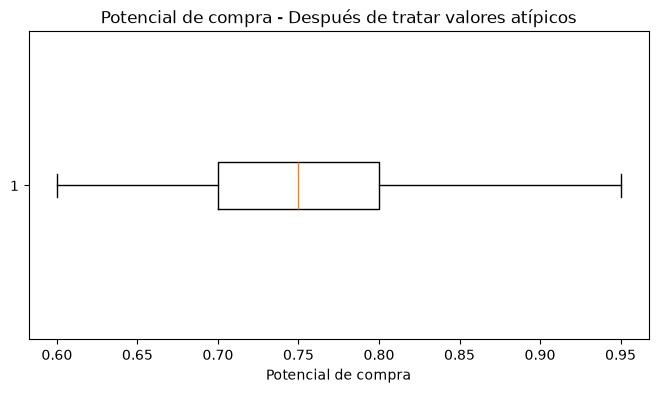

In [22]:
# Diagrama de caja después del tratamiento

plt.figure(figsize=(8,4))
plt.boxplot(data_clean["Potencial de compra"], vert=False)
plt.title("Potencial de compra - Después de tratar valores atípicos")
plt.xlabel("Potencial de compra")
plt.show()

In [23]:
#Convertir DataFrame a CSV

Datos_limpios.to_csv(
    "Citas_Digital_Sin_Outliers.csv",
    index=False
)